In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from utils.helpers import load_dataset, add_load_features

In [13]:
project_root = Path.cwd().parent.parent.parent

interval = 60
path = project_root / f"data/time_series_{interval}.csv"
df = load_dataset(path)

In [14]:
target = "DE_load_actual_entsoe_transparency"
df = df[[target]]
df.head()

,DE_load_actual_entsoe_transparency
utc_timestamp,
2014-12-31 23:00:00+00:00,NaN
2015-01-01 00:00:00+00:00,41151.0
2015-01-01 01:00:00+00:00,40135.0
2015-01-01 02:00:00+00:00,39106.0
2015-01-01 03:00:00+00:00,38765.0


In [15]:
multiplier = 4 if interval == 15 else 1
model_type = "forecast"
horizon = 24

df = add_load_features(df, target, interval, model_type)

if model_type == "forecast":
    df["target_forecast"] = df[target].shift(-1 * horizon * multiplier)
    mask_valid_target = df["target_forecast"].notna() # Extract rows where target is valid (not null)
else:
    mask_valid_target = df[target].notna() # Extract rows where target is valid (not null)
    
df = df[mask_valid_target].copy() # Take into DataFrame only rows with valid target
print(df.shape)

(50377, 29)


In [16]:
df = df.dropna()
print(df.shape)

(50208, 29)


In [17]:
if model_type == "forecast":
    X = df.drop([target, "target_forecast"], axis=1).to_numpy()
    y = df["target_forecast"].to_numpy()

else:
    X = df.drop(target, axis=1).to_numpy()
    y = df[target].to_numpy()

print(X.shape, y.shape)

(50208, 27) (50208,)


In [18]:
from sklearn.model_selection import train_test_split

gap = 168 * multiplier
val_size = 168 * multiplier

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

X_val, y_val = X_train_full[-val_size:], y_train_full[-val_size:]
X_train, y_train = X_train_full[:-val_size - gap], y_train_full[:-val_size - gap]

In [19]:
from sklearn.kernel_approximation import RBFSampler
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

"""
# Found using train + test !!! not the best practice
1. (0.9373, {'gamma': 0.0075, 'components': 2000, 'alpha': 0.001})
"""

model_ridge = make_pipeline(
    StandardScaler(),
    RBFSampler(
        gamma=0.0075,
        n_components=2000,
        random_state=42
    ),
    Ridge(alpha=0.001)
)

model_ridge.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('rbfsampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,gamma,0.0075
,n_components,2000
,random_state,42
,alpha,0.001


In [20]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

y_pred = model_ridge.predict(X_train)
rmse = root_mean_squared_error(y_train, y_pred)
mae = mean_absolute_error(y_train, y_pred)
mape = mean_absolute_percentage_error(y_train, y_pred)*100
r2 = r2_score(y_train, y_pred)
nrmse = rmse / y_train.mean()
nrmse_pct = 100 * nrmse
print(f'Ridge model || Train RMSE: {rmse:.3f}, MAE: {mae:.3f}, MAPE: {mape:.3f}%, R2: {r2:.4f}, nRMSE: {nrmse_pct:.3f}%')

y_pred = model_ridge.predict(X_val)
rmse = root_mean_squared_error(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
mape = mean_absolute_percentage_error(y_val, y_pred)*100
r2 = r2_score(y_val, y_pred)
nrmse = rmse / y_val.mean()
nrmse_pct = 100 * nrmse
print(f'Ridge model || Validation RMSE: {rmse:.3f}, MAE: {mae:.3f}, MAPE: {mape:.3f}%, R2: {r2:.4f}, nRMSE: {nrmse_pct:.3f}%')

y_pred = model_ridge.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)*100
r2 = r2_score(y_test, y_pred)
nrmse = rmse / y_test.mean()
nrmse_pct = 100 * nrmse
print(f'Ridge model || Test RMSE: {rmse:.3f}, MAE: {mae:.3f}, MAPE: {mape:.3f}%, R2: {r2:.4f}, nRMSE: {nrmse_pct:.3f}%')

Ridge model || Train RMSE: 1847.177, MAE: 1152.274, MAPE: 2.133%, R2: 0.9660, nRMSE: 3.301%
Ridge model || Validation RMSE: 848.784, MAE: 657.694, MAPE: 1.378%, R2: 0.9912, nRMSE: 1.652%
Ridge model || Test RMSE: 2463.867, MAE: 1632.938, MAPE: 3.194%, R2: 0.9373, nRMSE: 4.580%


In [21]:
"""
Best RMSE: 2424.1972
Best params: {'rbfsampler__gamma': 0.010947678332359876, 'ridge__alpha': 0.027336728850858555, 'rbfsampler__n_components': 1950}
"""

model_ridge = make_pipeline(
    StandardScaler(),
    RBFSampler(
        gamma=0.010947678332359876,
        n_components=1950,
        random_state=42
    ),
    Ridge(alpha=0.027336728850858555)
)

model_ridge.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('rbfsampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,gamma,0.010947678332359876
,n_components,1950
,random_state,42
,alpha,0.027336728850858555


In [22]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

y_pred = model_ridge.predict(X_train)
rmse = root_mean_squared_error(y_train, y_pred)
mae = mean_absolute_error(y_train, y_pred)
mape = mean_absolute_percentage_error(y_train, y_pred)*100
r2 = r2_score(y_train, y_pred)
nrmse = rmse / y_train.mean()
nrmse_pct = 100 * nrmse
print(f'Ridge model || Train RMSE: {rmse:.3f}, MAE: {mae:.3f}, MAPE: {mape:.3f}%, R2: {r2:.4f}, nRMSE: {nrmse_pct:.3f}%')

y_pred = model_ridge.predict(X_val)
rmse = root_mean_squared_error(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
mape = mean_absolute_percentage_error(y_val, y_pred)*100
r2 = r2_score(y_val, y_pred)
nrmse = rmse / y_val.mean()
nrmse_pct = 100 * nrmse
print(f'Ridge model || Validation RMSE: {rmse:.3f}, MAE: {mae:.3f}, MAPE: {mape:.3f}%, R2: {r2:.4f}, nRMSE: {nrmse_pct:.3f}%')

y_pred = model_ridge.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)*100
r2 = r2_score(y_test, y_pred)
nrmse = rmse / y_test.mean()
nrmse_pct = 100 * nrmse
print(f'Ridge model || Test RMSE: {rmse:.3f}, MAE: {mae:.3f}, MAPE: {mape:.3f}%, R2: {r2:.4f}, nRMSE: {nrmse_pct:.3f}%')

Ridge model || Train RMSE: 1978.922, MAE: 1219.625, MAPE: 2.267%, R2: 0.9610, nRMSE: 3.536%
Ridge model || Validation RMSE: 1053.214, MAE: 847.536, MAPE: 1.760%, R2: 0.9864, nRMSE: 2.049%
Ridge model || Test RMSE: 2800.412, MAE: 1819.995, MAPE: 3.647%, R2: 0.9190, nRMSE: 5.206%


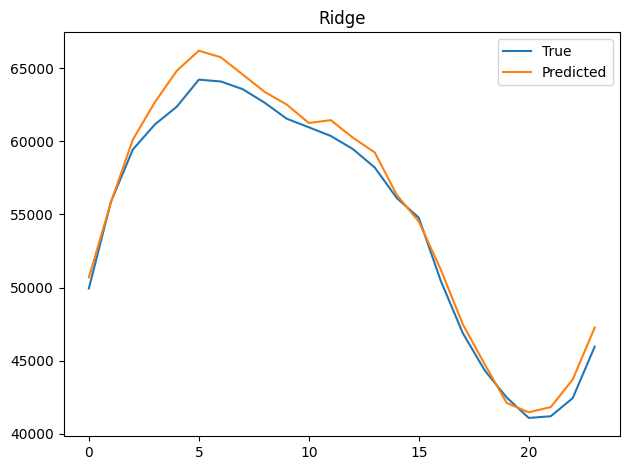

In [23]:
window = 24*multiplier
idx = np.random.randint(0, len(X_test) - window)

y_pred = model_ridge.predict(X_test[idx:idx+window])

plt.plot(range(len(X_test[idx:idx+window])), y_test[idx:idx+window], label="True")
plt.plot(range(len(X_test[idx:idx+window])), y_pred, label="Predicted")
plt.title("Ridge")
plt.legend()

plt.tight_layout()
plt.show()